# Assignment Description: 
This assignment focuses on improving the performance of an image classification model using Convolutional 
Neural Networks (CNN). 

A basic CNN model is first implemented and trained on the Intel Image Classification 
Dataset. 

Then, different techniques such as data augmentation, pretrained VGG16, feature extraction, and fine tuning 
are applied to enhance the model’s accuracy. 

The results of all five approaches are compared to analyse which 
technique performs best for image classification  

# Assignment Objectives: 

In this assignment you will apply five different CNN techniques to improve the performance of an image 
classification model on a challenging dataset. 

You will start with a basic CNN model and gradually improve performance using modern deep learning 
techniques. 

#Assignment Guidelines: 

**Dataset:**
Intel Image Classification Dataset 

https://www.kaggle.com/datasets/puneet6060/intel-image-classification 

Classes include: 

• buildings 

• forest 

• glacier 

• mountain 

• sea 

• street

**1. Basic Convolutional Network** 

Train a simple CNN from scratch. 

Example architecture: 

Conv → ReLU → MaxPool 

Conv → ReLU → MaxPool 

Flatten 

Dense 

Softmax 

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.4900 - loss: 1.3451 - val_accuracy: 0.6702 - val_loss: 0.8521
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - accuracy: 0.7156 - loss: 0.7608 - val_accuracy: 0.7494 - val_loss: 0.6764
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.7834 - loss: 0.5862 - val_accuracy: 0.7583 - val_loss: 0.6606
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.8346 - loss: 0.4557 - val_accuracy: 0.7868 - val_loss: 0.6000
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.8587 - loss: 0.3928 - val_accuracy: 0.8111 - val_loss: 0.5409
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.8942 - loss: 0.2953 - val_accuracy: 0.8128 - val_loss: 0.5728
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.9307 - loss: 0.207

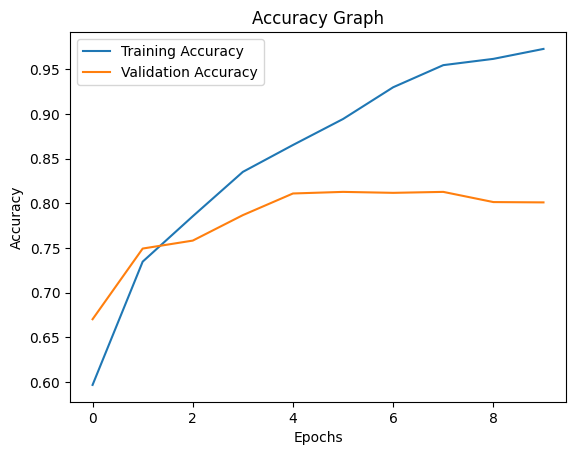

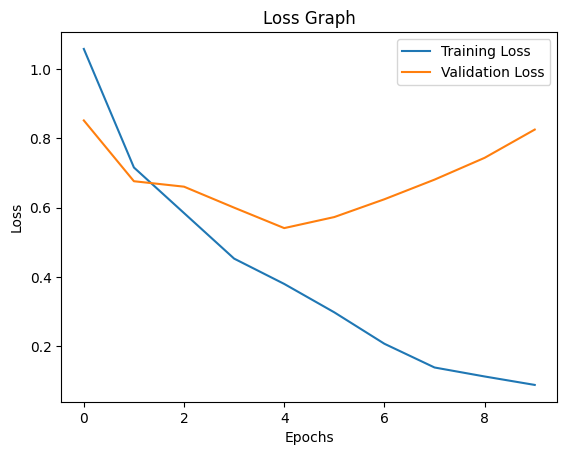

In [2]:
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt

# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

# Data generators (NO validation_split here)
train_datagen = ImageDataGenerator(rescale=1./255)

# Training data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),   # reduced size (faster)
    batch_size=64,           # bigger batch
    class_mode='categorical' # multi-class
)

# Validation data
val_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='categorical'
)
# Test data
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

# CNN Model (modern style)
model = models.Sequential([
    Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256,activation='relu'),

    # IMPORTANT: match number of classes
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile model
model.compile(
    loss='categorical_crossentropy',  # correct for multi-class
    optimizer=optimizers.Adam(learning_rate=1e-3),  # faster than RMSprop
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_generator,
    epochs=10,   # start small
    validation_data=validation_generator
)

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

**2. Data Augmentation** 

Apply augmentation techniques such as: 

• rotation 

• horizontal flip 

• zoom 

• width/height shift 

Train the CNN again and compare results. 

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Epoch 1/15
 10/176 ━━━━━━━━━━━━━━━━━━━━ 42s 259ms/step - accuracy: 0.1500 - loss: 2.6047

2026-03-27 13:00:23.255192: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-filter.5 = (f16[64,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[29,63,63,32]{3,2,1,0} %bitcast.6018, f16[29,61,61,64]{3,2,1,0} %bitcast.6043), window={size=3x3}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/sequential_2_1/conv2d_7_1/convolution/Conv2DBackpropFilter" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-03-27 13:00:23.610465: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.355386597s
Trying algorithm eng0{} for

176/176 ━━━━━━━━━━━━━━━━━━━━ 76s 362ms/step - accuracy: 0.4387 - loss: 1.4979 - val_accuracy: 0.6652 - val_loss: 0.8637
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 311ms/step - accuracy: 0.6433 - loss: 0.9376 - val_accuracy: 0.6635 - val_loss: 0.9482
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 54s 309ms/step - accuracy: 0.6882 - loss: 0.8036 - val_accuracy: 0.7569 - val_loss: 0.6748
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.7338 - loss: 0.7184 - val_accuracy: 0.7547 - val_loss: 0.6596
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.7510 - loss: 0.6784 - val_accuracy: 0.7269 - val_loss: 0.7331
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.7499 - loss: 0.6733 - val_accuracy: 0.7993 - val_loss: 0.5456
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 313ms/step - accuracy: 0.7738 - loss: 0.6193 - val_accuracy: 0.7462 - val_loss: 0.7171
Epoch 8/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 316ms/step - accuracy: 0.7875 - loss: 0.5823 - val

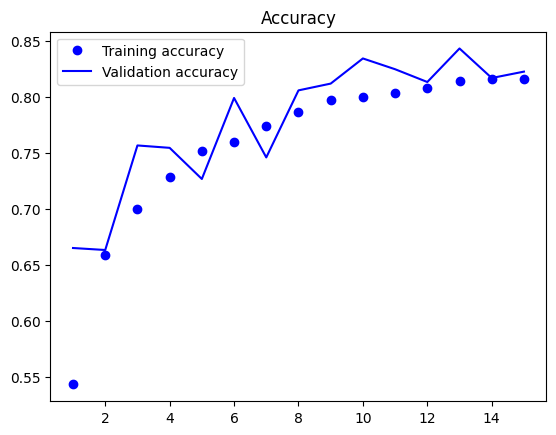

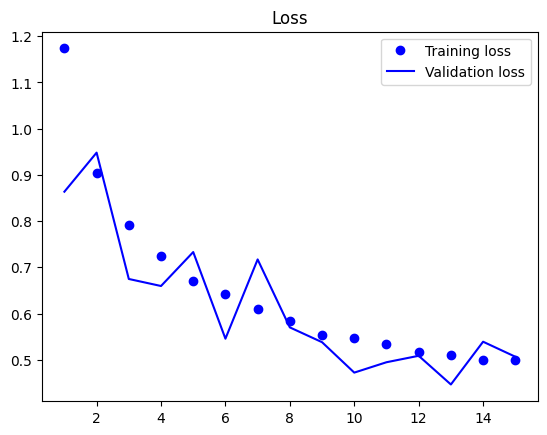

In [3]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

# Enable GPU optimization
mixed_precision.set_global_policy('mixed_float16')

# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

# Faster config
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

# Image Augmentation (train only)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # reduced (faster)
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # auto multi-class
)

validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Check classes
print("Classes:", train_generator.class_indices)

# Model
model = models.Sequential([
    Input(shape=(128,128,3)),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dropout(0.5),

    layers.Dense(256,activation='relu'),

    # auto match classes
    layers.Dense(train_generator.num_classes, activation='softmax')
])

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-3),  # 🔥 faster
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    epochs=15,   # reduced (faster)
    validation_data=validation_generator
)

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Save model
#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/augmentation_model2.h5")

# Plot
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training accuracy')
plt.plot(epochs,val_acc,'b',label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs,loss,'bo',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

**3. Pretrained CNN (VGG16)** 

Use VGG16 pretrained on ImageNet. 

Freeze the convolutional base and train only the classifier.

Found 3000 images belonging to 6 classes.
Found 11229 images belonging to 6 classes.
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step
Found 2805 images belonging to 6 classes.
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step
Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5708 - loss: 1.1052 - val_accuracy: 0.8207 - val_loss: 0.5024
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8066 - loss: 0.5336 - val_accuracy: 0.8339 - val_loss: 0.4480
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8351 - loss: 0.4517 - val_accuracy: 0.8481 - val_loss: 0.4079
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8403 - loss: 0.4296 - val_accuracy: 0.8602 - val_loss: 0.3898
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8564 - loss: 0.4023 - val_accuracy: 0.8592 - val_loss: 0.3872
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8524 - loss: 0.3872 - val_accuracy: 0.8610 - val_loss: 0.3795
Epoch 7/15
176/176 

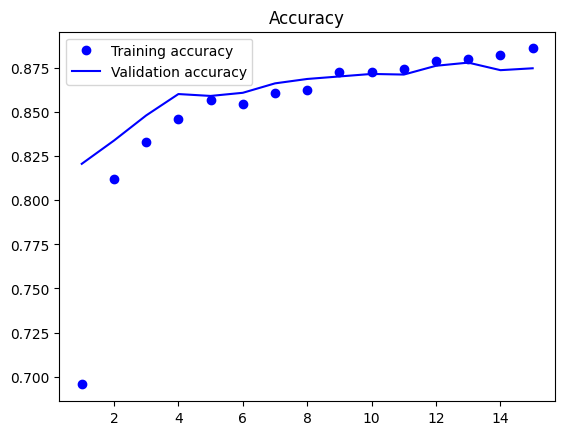

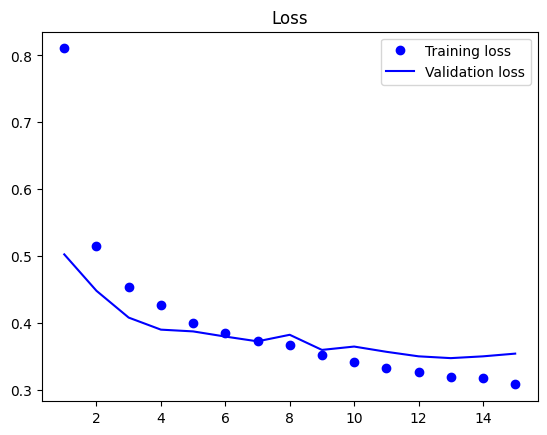

In [2]:
# Load VGG16
from tensorflow.keras.applications import VGG16

conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)   # 🔥 reduced size (faster)
)

conv_base.trainable = False   # 🔥 freeze for speed


# Data Generator
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

IMG_SIZE = (128, 128)
BATCH_SIZE = 64

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64   # faster


def extract_features(directory):

    generator = datagen.flow_from_directory(
        directory,
        target_size=(128,128),
        batch_size=BATCH_SIZE,
        class_mode='categorical',   # 🔥 multi-class
        shuffle=False
    )

    features = conv_base.predict(generator, verbose=1)
    labels = generator.classes

    return features, labels, generator.num_classes


# Extract features
train_features, train_labels, num_classes = extract_features(train_dir)
val_features, val_labels, _ = extract_features(validation_dir)


# 🔥 Better than flatten (reduces size)
from tensorflow.keras.layers import GlobalAveragePooling2D

train_features = train_features.mean(axis=(1,2))
val_features = val_features.mean(axis=(1,2))


# Convert labels to categorical
from tensorflow.keras.utils import to_categorical

train_labels = to_categorical(train_labels, num_classes)
val_labels = to_categorical(val_labels, num_classes)


# Dense classifier
from tensorflow.keras import models, layers, optimizers

model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(512,)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # 🔥 auto classes
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),  # 🔥 faster
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# Train
history = model.fit(
    train_features,
    train_labels,
    epochs=15,           # 🔥 reduced
    batch_size=64,
    validation_data=(val_features, val_labels)
)

# Extract test features
test_features, test_labels, _ = extract_features(test_dir)

test_features = test_features.mean(axis=(1,2))
test_labels = to_categorical(test_labels, num_classes)

# Evaluate
test_loss, test_acc = model.evaluate(test_features, test_labels)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_feature_model.h5")

# Plot
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)

plt.plot(epochs,acc,'bo',label='Training accuracy')
plt.plot(epochs,val_acc,'b',label='Validation accuracy')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs,loss,'bo',label='Training loss')
plt.plot(epochs,val_loss,'b',label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

# 4. Feature Extraction 

Use VGG16 to extract features, then train a small classifier on top. 

Steps: 

Image → VGG16 (frozen) → feature vector → classifier 

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Found 3000 images belonging to 6 classes.
Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 68s 372ms/step - accuracy: 0.2417 - loss: 1.8006 - val_accuracy: 0.6923 - val_loss: 1.2073
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 72s 411ms/step - accuracy: 0.5451 - loss: 1.2020 - val_accuracy: 0.7483 - val_loss: 0.9091
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 59s 334ms/step - accuracy: 0.6736 - loss: 0.9394 - val_accuracy: 0.7740 - val_loss: 0.7637
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 59s 334ms/step - accuracy: 0.6935 - loss: 0.8453 - val_accuracy: 0.7847 - val_loss: 0.6931
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 59s 334ms/step - accuracy: 0.7276 - loss: 0.7702 - val_accuracy: 0.7993 - val_loss: 0.6365
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 343ms/step - accuracy: 0.7285 - loss: 0.7299 - val_accuracy: 0.7971 - val_loss: 0.6

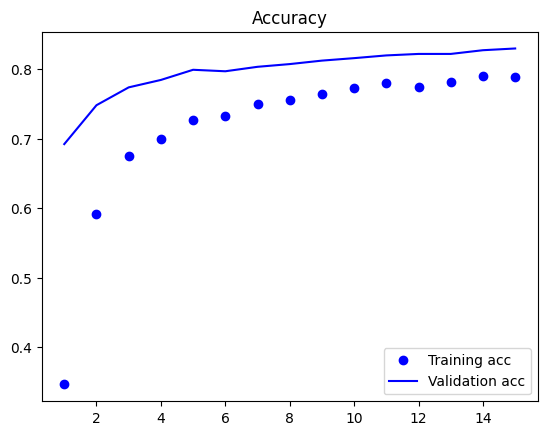

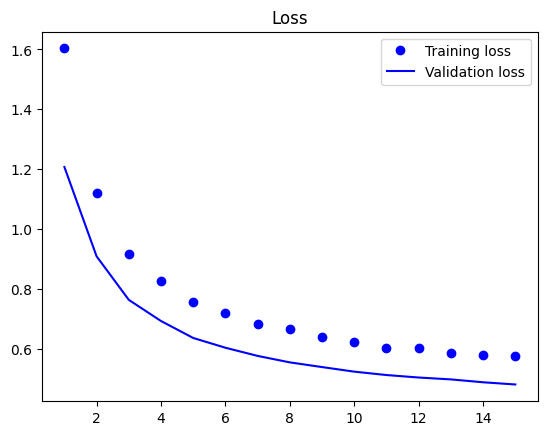

In [3]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

# Load VGG16
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

conv_base.trainable = False

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128,128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

# 🔍 Check classes
print("Classes:", train_generator.class_indices)
num_classes = train_generator.num_classes

IMG_SIZE = (128, 128)
BATCH_SIZE = 64

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Model
model = models.Sequential([
    Input(shape=(128,128,3)),
    conv_base,
    GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # ✅ changed
])

# Compile
model.compile(
    loss='categorical_crossentropy',   # ✅ changed
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# Save model
# model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_categorical.keras")

# Plot
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

**5. Fine Tuning**

Unfreeze the top layers of VGG16 and retrain them along with the classifier. 

This allows the network to adapt to the dataset.

Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 63s 345ms/step - accuracy: 0.2762 - loss: 1.7351 - val_accuracy: 0.7012 - val_loss: 1.1634
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 68s 387ms/step - accuracy: 0.5668 - loss: 1.1643 - val_accuracy: 0.7483 - val_loss: 0.8969
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 62s 350ms/step - accuracy: 0.6509 - loss: 0.9544 - val_accuracy: 0.7679 - val_loss: 0.7689
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 64s 364ms/step - accuracy: 0.6972 - loss: 0.8280 - val_accuracy: 0.7758 - val_loss: 0.6923
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 342ms/step - accuracy: 0.7198 - loss: 0.7669 - val_accuracy: 0.7911 - val_loss: 0.6458
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 66s 373ms/step - accuracy: 0.7419 - loss: 0.7189 - val_accuracy: 0.7975 - val_loss: 0.6

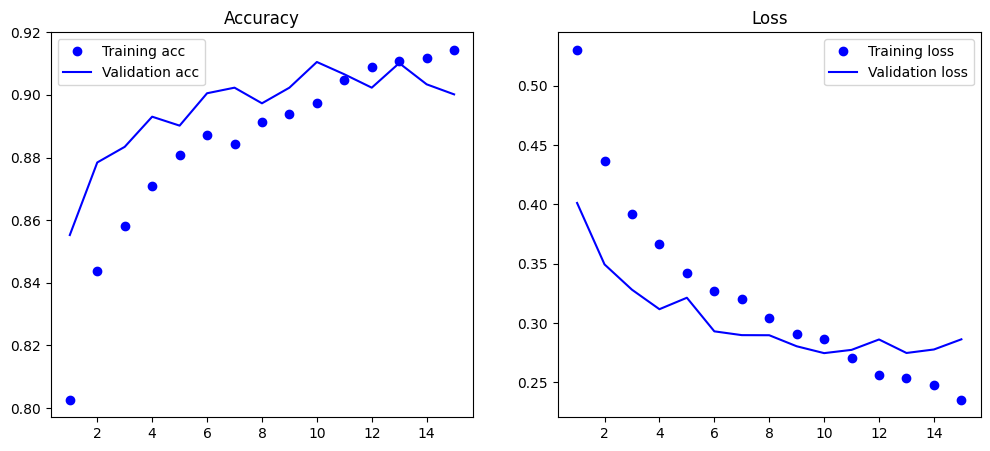

In [4]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt
# Dataset paths
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"

# Load VGG16 base
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)   # ⚡ faster
)

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128, 128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

IMG_SIZE = (128, 128)
BATCH_SIZE = 64

test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)
# 🔍 Check classes
print("Classes:", train_generator.class_indices)
num_classes = train_generator.num_classes

# Build model (better than Flatten)
model = models.Sequential([
    Input(shape=(128,128,3)),
    conv_base,
    GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # ✅ changed
])

# Freeze base initially
conv_base.trainable = False

# Compile (initial training)
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train top layers
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# 🔥 Fine-tuning (unfreeze last layers)
conv_base.trainable = True

for layer in conv_base.layers[:-4]:   # keep most frozen
    layer.trainable = False

# Recompile with lower LR
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

# Fine-tune
history_fine = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator
)

test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

# 💾 Save model
#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_finetuned.keras")

# Plot results
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()

| Model | Type                     | Validation Accuracy |
| ----- | ------------------------ | ------------------- |
| 1️⃣   | Simple CNN               | **0.8011**          |
| 2️⃣   | CNN + Augmentation       | **0.8228**          |
| 3️⃣   | VGG16 Feature Extraction | **0.8749**          |
| 4️⃣   | VGG16 + Augmentation     | **0.8299**          |
| 5️⃣   | VGG16 + Fine-tuning      | **0.9002**          |


🔹 1. Simple CNN → Baseline - 0.8011

Model is learning basic patterns

Limited feature extraction

Good starting point

🔹 2. Augmentation →  0.8228

Helps generalization


🔹 3. VGG16 Feature Extraction → BIG JUMP - 0.8749

This is expected: Uses pretrained knowledge (ImageNet)

Strong feature extractor

Huge improvement over CNN

4. VGG16 + Augmentation → DROP - 0.8299 - This is interesting

Possible Reasons:

Too much augmentation (over-distortion)

Model already strong → augmentation adds noise

Underfitting due to frozen layers

This is a common real-world scenario

5. VGG16 + Fine-Tuning → BEST - 0.9002

Highest accuracy

Model adapts to your dataset

This is your final best model

**Overall Trend : CNN → +Aug → +VGG → +Aug(VGG) ↓ → +FineTune ↑**

Key takeaway:

Transfer learning > Custom CNN

Fine-tuning > Feature extraction

Too much augmentation can hurt

**Final Conclusion Best Model**

1.VGG16 + Fine-tuning (0.9002)

2.VGG16 Feature Extraction (0.8749)